In [1]:

import torch
from torch.utils.data import DataLoader
import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import sys
import os
from itertools import accumulate

sys.path.append("..")
from src import models, datasets, trainer, analysis

In [2]:
sns.set_theme(
    style="ticks",
    palette=sns.color_palette("mako", 10),
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2.5,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

In [3]:

def linear_kernel_hsic(X, Y):
    # Hilbert-Schmidt Independence Criterion (HSIC) calculation for linear kernels
    # X and Y should be of centered matrices of dim n,p and n,q respectively, with n>1
    n = X.shape[0]
    return np.trace(X @ X.T @ Y @ Y.T)/((n-1)**2)

def hsic(K, L):
    # General form of Hilbert-Schmidt Independence Criterion (HSIC)
    # if kernels used to produce K and L (both nxn matrices) is the linear kernel, equiv to the above
    n = K.shape[0]
    H = np.eye(n, n) - np.ones((n, n)) / n
    return np.trace((K @ H) @ (L @ H)) / ((n-1)**2)

def apply_linear_kernel(X):
    # apply linear kernel to rows of X. X should be a nxp matrix. Just here for completeness.
    return X @ X.T

def apply_RBF_kernel(X, sigma=None):
    # Apply the RBF kernel to a matrix row-wise. X should be a nxp matrix. Returns a nxn matrix K.
    # RBF kernel: k(X_i, X_j) = exp(-||X_i - X_j||_2^2/(2*sigma^2)) for rows i and j of X
    if sigma is None:
        pairwise_dists = np.sqrt(np.sum((X[:, np.newaxis] - X) ** 2, axis=-1))
        sigma = np.median(pairwise_dists)
    denominator = 2 * (sigma ** 2)
    pairwise_sq_dists = np.sum((X[:, np.newaxis] - X) ** 2, axis=-1)
    K = np.exp(-pairwise_sq_dists / denominator)
    return K


In [4]:
# Generate X, a random 100 x 1000 matrix
X = np.random.rand(100, 1000)

# Generate Y, a random 100 x 5000 matrix
Y = np.random.rand(100, 5000)

# Center the data
X_centered = X - np.mean(X, axis=0)
Y_centered = Y - np.mean(Y, axis=0)

# Apply the linear kernel to X and Y
K_X = apply_linear_kernel(X_centered)
K_Y = apply_linear_kernel(Y_centered)

# Compute the HSIC valueusing the linear kernel
hsic_value_linear = hsic(K_X, K_Y)
print(f"HSIC value using linear kernel: {hsic_value_linear}")

# Now apply the linear_kernel_hsic function directly to the centered data
hsic_value_direct = linear_kernel_hsic(X_centered, Y_centered)
print(f"HSIC value using linear_kernel_hsic function: {hsic_value_direct}")

HSIC value using linear kernel: 349.89749618889067
HSIC value using linear_kernel_hsic function: 349.89749618889067


In [5]:
# now quickly testing with the RBF kernel
K_X_rbf = apply_RBF_kernel(X_centered)
K_Y_rbf = apply_RBF_kernel(Y_centered)
hsic_value_rbf = hsic(K_X_rbf, K_Y_rbf)
print(f"HSIC value using RBF kernel: {hsic_value_rbf}")

HSIC value using RBF kernel: 0.0015645537273158905


In [6]:
def CKA(X, Y, kernel_func):
    """
    Calculates the Centered Kernel Alignment between centered matrices X (nxp) and Y (nxq), using the kernel function specified by kernel_func
    """
    K_X = kernel_func(X)
    K_Y = kernel_func(Y)

    n = K_X.shape[0]
    H = np.eye(n, n) - np.ones((n, n)) / n

    centered_K = K_X @ H
    centered_L = K_Y @ H

    result = np.trace(centered_K @ centered_L) / np.sqrt(np.trace(centered_K @ centered_K) * np.trace(centered_L @ centered_L))

    return result

def linear_CKA_fast(X, Y):
    """
    Linear CKA between (n, p) and (n, q) matrices.
    Computes in feature space: cost is O(n*p*q), no n x n matrix ever formed.
    Assumes X, Y are already mean-centered along axis 0.
    """
    # cross-covariance and self-covariances (p x q, p x p, q x q)
    XtY = X.T @ Y
    XtX = X.T @ X
    YtY = Y.T @ Y

    hsic_xy = np.sum(XtY ** 2)          # ||X^T Y||_F^2  == tr(K_X K_Y)
    hsic_xx = np.sqrt(np.sum(XtX ** 2)) # ||X^T X||_F
    hsic_yy = np.sqrt(np.sum(YtY ** 2)) # ||Y^T Y||_F

    return hsic_xy / (hsic_xx * hsic_yy)

In [7]:
# test with same matrices

#CKA with linear kernel function
cka_linear = CKA(X_centered, Y_centered, apply_linear_kernel)
print(f"CKA value using linear kernel: {cka_linear}")

# CKA with RBF kernel function
cka_rbf = CKA(X_centered, Y_centered, apply_RBF_kernel)
print(f"CKA value using RBF kernel: {cka_rbf}")

CKA value using linear kernel: 0.9450369923154863
CKA value using RBF kernel: 0.9664340613830371


# Loading in RNNs

In [8]:
results_dir = 'final'
results_dir = 'aidan_sigma'
# autocorr = 0.9
# ktau = 1.9
zeroint = False
delay = 2.0
dist = 'normal'
etas = [0.0, 0.1, 0.25, 0.5, 1.0]

if results_dir =='final':
    etas = [0.0, 0.1, 0.25, 0.5]
sigma = 0.1

# dd[eta][model/run_folder]
# keys: n_trials, best_model, epoch100, 200, 300... etc.

dd = {}
for eta in etas:
    print(f'eta={eta}')
    dd[eta] = {}

    if results_dir == 'final':
        if eta == 0.0:
            result_files = glob.glob(f'../rnn_results/{results_dir}/autocorr{autocorr}_ktau{ktau}_zeroint{zeroint}_delay{delay}_vanilla1.0_seed*')
        else:
            result_files = glob.glob(f'../rnn_results/{results_dir}/autocorr{autocorr}_ktau{ktau}_zeroint{zeroint}_delay{delay}_normal_eta{eta}_seed*')
    else:
        if eta == 0.0:
            result_files = glob.glob(f'../rnn_results/{results_dir}/zeroint{zeroint}_delay{delay}_vanilla1.0_sigma{sigma}_seed*')
        else:
            result_files = glob.glob(f'../rnn_results/{results_dir}/zeroint{zeroint}_delay{delay}_normal_eta{eta}_sigma{sigma}_seed*')


    for idx, dir in enumerate(result_files):
        # if idx <= 10:
        if idx%10 == 0:
            print(idx)
        name = int(dir.split('seed')[-1])
        dd[eta][name] = {}
        dd[eta][name]['n_trials'] = np.load(dir+'/train_losses.npy').shape[0]
        dd[eta][name]['best'] = torch.load(dir+'/best_model.pth')
        with open(dir+'/config.yaml', 'r') as f:
            dd[eta][name]['conf'] = yaml.safe_load(f)
        # checkpoints = glob.glob(dir+'/checkpoint_epoch*.pth')
        # for checkpoint in checkpoints:
        #     n_epoch = checkpoint.split('_')[-1].split('.')[0][-3:]
        #     dd[eta][dir][n_epoch] = torch.load(checkpoint)


### dd is a dict of first keys:
### eta
### seed #
### 'n_trials' or 'best', for this only need 'best'

eta=0.0
0
10
20
30
eta=0.1
0
10
20
30
eta=0.25
0
10
20
30
eta=0.5
0
10
20
30
eta=1.0
0
10
20
30


In [9]:
def get_tau_array(
    distribution,
    hidden_size,
    device,
    tau_groups=None,
    tau_proportions=None,
    tau_min=None,
    tau_max=None,
    tau_mean1=None,
    tau_mean2=None,
    tau_std1=None,
    tau_std2=None,
    tau_change=None,
    eta=None
):
    """Build a tau array according to the specified distribution."""
    if distribution == "groups":
        tau_array = torch.zeros(hidden_size, dtype=torch.float32, device=device)
        tau_sizes = [int(p * hidden_size) for p in tau_proportions]
        tau_indices = [0] + list(accumulate(tau_sizes))
        for i, tau in enumerate(tau_groups):
            tau_array[tau_indices[i]:tau_indices[i + 1]] = tau
        return tau_array

    if distribution == "uniform":
        if tau_min is None or tau_max is None:
            raise ValueError(
                "tau_min and tau_max must be provided for uniform distribution."
            )
        return torch.FloatTensor(hidden_size).uniform_(tau_min, tau_max).to(device)

    if distribution == "bimodal_normal":
        tau_array = torch.zeros(hidden_size, dtype=torch.float32, device=device)
        tau_sizes = [int(p * hidden_size) for p in tau_proportions]
        tau_indices = [0] + list(accumulate(tau_sizes))

        # Order the two modes by mean value
        if tau_mean1 <= tau_mean2:
            lesser_mean, greater_mean = tau_mean1, tau_mean2
            lesser_std, greater_std = tau_std1, tau_std2
        else:
            lesser_mean, greater_mean = tau_mean2, tau_mean1
            lesser_std, greater_std = tau_std2, tau_std1

        # Lower mode (truncated below tau_change)
        a1 = (tau_min - lesser_mean) / lesser_std
        b1 = (tau_change - lesser_mean) / lesser_std
        tau_array[tau_indices[0]:tau_indices[1]] = torch.tensor(
            truncnorm.rvs(a1, b1, loc=lesser_mean, scale=lesser_std, size=tau_sizes[0])
        )

        # Upper mode (truncated above tau_change)
        a2 = (tau_change - greater_mean) / greater_std
        b2 = (tau_max - greater_mean) / greater_std
        tau_array[tau_indices[1]:tau_indices[2]] = torch.tensor(
            truncnorm.rvs(a2, b2, loc=greater_mean, scale=greater_std, size=tau_sizes[1])
        )

        return tau_array
    
    if distribution == 'normal':
        return torch.exp(torch.normal(mean=tau_mean1, std=tau_std1, size=(hidden_size,))*eta).to(device)

    raise ValueError(f"Unsupported tau distribution type: '{distribution}'.")

def _build_tau_array(conf, device):
    """Helper: build the tau array from model config."""
    distribution = conf["model"]["tau_distribution"]
    hidden_size = conf["model"]["hidden_size"]
    m = conf["model"]

    if distribution == "groups":
        return get_tau_array(
            distribution, hidden_size, device,
            tau_groups=m["tau_groups"],
            tau_proportions=m["tau_proportions"],
        )
    if distribution == "uniform":
        return get_tau_array(
            distribution, hidden_size, device,
            tau_min=m["tau_min"],
            tau_max=m["tau_max"],
        )
    if distribution == "bimodal_normal":
        return get_tau_array(
            distribution, hidden_size, device,
            tau_proportions=m["tau_proportions"],
            tau_mean1=m["tau_mean1"], tau_mean2=m["tau_mean2"],
            tau_std1=m["tau_std1"], tau_std2=m["tau_std2"],
            tau_min=m["tau_min"], tau_max=m["tau_max"],
            tau_change=m["tau_change"],
        )
    if distribution == "normal":
        return get_tau_array(
            distribution, hidden_size, device,
            tau_mean1=m["tau_mean1"], tau_std1=m["tau_std1"],
            eta=m["eta"],
        )
    
    raise ValueError(f"Unsupported tau distribution type: '{distribution}'.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
def get_CKA_for_eta(eta_dict, alldata, n_trials, model, device):
    
    ckas = []
    for seed in eta_dict:
        print(f'seed {seed}')
        conf = eta_dict[seed]['conf']
        m = conf['model']
        tau_array = _build_tau_array(conf, device)
        
        fitmodel = model(m["input_size"], m["hidden_size"], m["output_size"],
                m["dt"], tau_array, m["activation"], m["tau_effect"],
                m["bias"], m["sigma_in"], m["sigma_re"], m["sigma"]) # change this for final vs sigma
        fitmodel.load_state_dict(eta_dict[seed]['best'])
        
        unfitmodel = model(m["input_size"], m["hidden_size"], m["output_size"],
                m["dt"], tau_array, m["activation"], m["tau_effect"],
                m["bias"], m["sigma_in"], m["sigma_re"], m["sigma"]) # change this for final vs sigma
        
        fitmodel.eval()
        unfitmodel.eval()
        
        h_fit_all, h_unfit_all = [], []

        with torch.no_grad():
            for trial_idx in range(n_trials):
                if trial_idx%10 == 0:
                    print(f'trial {trial_idx}')
                inputs, _ = alldata[trial_idx]

                if inputs.ndimension() == 2:
                    inputs = inputs.unsqueeze(0)       # (1, T, input_size) = (1, 2001, 1)
                batch_size = inputs.size(0)             # now correctly 1
                hidden = fitmodel.init_hidden(batch_size, device)
                
                # same input to both models, take the hidden trajectory (3rd return)
                _, _, h  = fitmodel(inputs, hidden, noise=False, returnstates=True)   # (B, T, H)
                _, _, h2 = unfitmodel(inputs, hidden, noise=False, returnstates=True) # (B, T, H)

                # # Inside the loop, after computing h and h2:
                # h_np  = h.cpu().numpy()[-1, :]   # (H,)
                # h2_np = h2.cpu().numpy()[-1, :]  # (H,)

                # print("h_fit == h_unfit?", np.allclose(h_np, h2_np))
                # print("Max diff:", np.max(np.abs(h_np - h2_np)))
                
                h_fit_all.append(h.cpu().numpy())    # (T, H)
                h_unfit_all.append(h2.cpu().numpy()) # (T, H)

        # h_fit_all is a list of (B, T, H) arrays
        h_fit_all  = np.concatenate(h_fit_all, axis=0)    # (sum_B, T, H)
        h_unfit_all = np.concatenate(h_unfit_all, axis=0)

        # reshape to (samples, H): each (trial, timestep) pair is one sample
        h_fit_all  = h_fit_all.reshape(-1, h_fit_all.shape[-1])    # (sum_B*T, H)
        h_unfit_all = h_unfit_all.reshape(-1, h_unfit_all.shape[-1])

        h_fit_all  -= np.mean(h_fit_all, axis=0)
        h_unfit_all -= np.mean(h_unfit_all, axis=0)

        # print("h_fit_all shape:", h_fit_all.shape)
        # print("h_unfit_all shape:", h_unfit_all.shape)
        # print("h shape from model:", h.shape)            # expect (T, H)?
        # print("h_fit_all shape:", h_fit_all.shape)
        # u, s, vt = np.linalg.svd(h_fit_all, full_matrices=False)
        # print("singular values:", s[:10])
        # print("rank-1 fraction:", s[0]**2 / np.sum(s**2))

        # # Are the Gram matrices actually different?
        # K_fit   = h_fit_all @ h_fit_all.T
        # K_unfit = h_unfit_all @ h_unfit_all.T
        # print("Kernel max diff:", np.max(np.abs(K_fit - K_unfit)))

        # # Is the representation rank-1? (that alone gives CKA=1)
        # eigvals = np.linalg.eigvalsh(K_fit)[::-1]
        # print("Top eigenvalues:", eigvals[:5])
        # print("Explained by rank-1:", eigvals[0] / eigvals.sum())
        
        cka_value = linear_CKA_fast(h_fit_all, h_unfit_all)
        print(f"CKA: {cka_value:.6f}")
        ckas.append(cka_value)
    
    return ckas

In [11]:
### test 
seed = 0

if results_dir == 'final':
    base_model = models.expirimental_RNN_temp
    expt_idx = 20
else:
    base_model = models.expirimental_RNN_sigmainit
    expt_idx = 0

expt = dd[0.0][expt_idx]['conf']['expt']

alldata = datasets.NonstationaryRewardDelayDataset(
            seed,
            kernel_tau=expt["kernel_tau"], read_delay=expt["read_delay"], autocorr=expt["autocorr"],
            noise_std=expt['noise_std'],  zero_integration=expt['zero_integration'],
        )

trial = 0

data = alldata[trial]

In [12]:
def getCKAs(full_dict, etas, alldata, n_trials, model, device):

    allckas = {}
    means = []
    stdevs = []
    for eta in etas:
        print(eta)
        allckas[eta] = get_CKA_for_eta(full_dict[eta], alldata, n_trials, model, device)
        means.append(np.mean(np.array(allckas[eta])))
        stdevs.append(np.std(np.array(allckas[eta])))

    return allckas, means, stdevs

In [13]:
allckas, means, stdevs = getCKAs(dd, etas, alldata, 20, base_model, device)

0.0
seed 0
trial 0
trial 10
CKA: 0.033930
seed 1
trial 0
trial 10
CKA: 0.047469
seed 10
trial 0
trial 10
CKA: 0.049941
seed 11
trial 0
trial 10
CKA: 0.055414
seed 12
trial 0
trial 10
CKA: 0.044591
seed 13
trial 0
trial 10
CKA: 0.048758
seed 14
trial 0
trial 10
CKA: 0.041514
seed 15
trial 0
trial 10
CKA: 0.402914
seed 16
trial 0
trial 10
CKA: 0.044963
seed 17
trial 0
trial 10
CKA: 0.033216
seed 18
trial 0
trial 10
CKA: 0.276371
seed 19
trial 0
trial 10
CKA: 0.467269
seed 2
trial 0
trial 10
CKA: 0.047214
seed 20
trial 0
trial 10
CKA: 0.040286
seed 21
trial 0
trial 10
CKA: 0.403633
seed 22
trial 0
trial 10
CKA: 0.011436
seed 23
trial 0
trial 10
CKA: 0.444749
seed 24
trial 0
trial 10
CKA: 0.052571
seed 25
trial 0
trial 10
CKA: 0.031375
seed 26
trial 0
trial 10
CKA: 0.353296
seed 27
trial 0
trial 10
CKA: 0.033807
seed 28
trial 0
trial 10
CKA: 0.026544
seed 29
trial 0
trial 10
CKA: 0.052701
seed 3
trial 0
trial 10
CKA: 0.359597
seed 30
trial 0
trial 10
CKA: 0.008314
seed 31
trial 0
trial 10


eta 0 vs 0.1: n=40/40, 40/40 after dropping NaNs
 raw p=0.1890, corrected p=0.7561 → ns
eta 0 vs 0.1: raw p=0.1890, corrected p=0.7561 → ns
eta 0.1 vs 0.25: n=40/40, 40/40 after dropping NaNs
 raw p=0.0727, corrected p=0.2909 → ns
eta 0.1 vs 0.25: raw p=0.0727, corrected p=0.2909 → ns
eta 0.25 vs 0.5: n=40/40, 40/40 after dropping NaNs
 raw p=0.0000, corrected p=0.0000 → ***
eta 0.25 vs 0.5: raw p=0.0000, corrected p=0.0000 → ***
eta 0.5 vs 1.0: n=40/40, 40/40 after dropping NaNs
 raw p=0.0000, corrected p=0.0000 → ***
eta 0.5 vs 1.0: raw p=0.0000, corrected p=0.0000 → ***


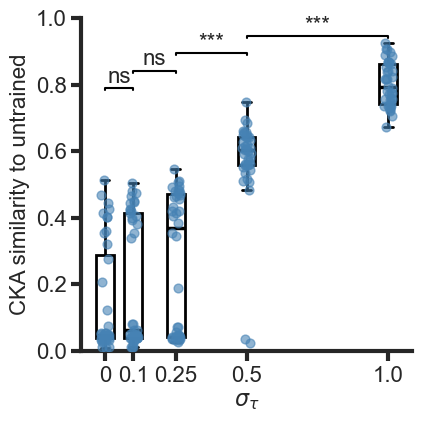

In [14]:
from scipy.stats import mannwhitneyu

fig, ax = plt.subplots(figsize=(4.5, 4.5))

data = [allckas[eta] for eta in etas]
labels = [0, 0.1, 0.25, 0.5, 1.0]
pos = [0, 0.4, 1.0, 2.0, 4.0]
widths = 0.15 # relative to pos spacing — tune as needed

rng = np.random.default_rng(0)
for d, p in zip(data, pos):
    d_clean = np.array(d)
    mask = ~np.isnan(d_clean)
    jitter = rng.uniform(-0.06, 0.06, size=mask.sum())
    ax.scatter(p + jitter, d_clean[mask], color="steelblue", alpha=0.6, s=40, zorder=3)

ax.boxplot(
    data,
    positions=pos,
    widths=0.25, # was 0.15
    manage_ticks=False,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black", linewidth=2), # added linewidth
    medianprops=dict(color="black", linewidth=2.5), # was 2
    whiskerprops=dict(color="black", linewidth=2), # added linewidth
    capprops=dict(color="black", linewidth=2), # added linewidth
    flierprops=dict(marker=""),
)

# Fixed significance label
def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

n_comparisons = len(pos) - 1
y_max = max(max(d) for d in data)
bar_gap = y_max * 0.07

for i in range(n_comparisons):
    p1, p2 = pos[i], pos[i+1]

    d1 = np.array(data[i])
    d2 = np.array(data[i+1])

    d1_clean = d1[~np.isnan(d1)]
    d2_clean = d2[~np.isnan(d2)]

    print(f"eta {labels[i]} vs {labels[i+1]}: n={len(d1_clean)}/{len(d1)}, {len(d2_clean)}/{len(d2)} after dropping NaNs")

    _, p_val = mannwhitneyu(d1_clean, d2_clean, alternative='two-sided')
    p_corrected = min(p_val * n_comparisons, 1.0)
    label = significance_label(p_corrected)
    print(f" raw p={p_val:.4f}, corrected p={p_corrected:.4f} → {label}")
    label = significance_label(p_corrected)
    print(f"eta {labels[i]} vs {labels[i+1]}: raw p={p_val:.4f}, corrected p={p_corrected:.4f} → {label}")

    bar_y = y_max + bar_gap * (i + 1)
    bar_y = bar_y*0.8
    ax.plot([p1, p1, p2, p2], [bar_y - bar_gap*0.1, bar_y, bar_y, bar_y - bar_gap*0.1],
            color='black', linewidth=1.5)
    ax.text((p1 + p2) / 2, bar_y + bar_gap * 0.05, label,
            ha='center', va='bottom')

ax.set_xticks(pos)
ax.set_xticklabels(labels)
ax.set_ylabel('CKA similarity to untrained')
ax.set_ylim(0,1)
ax.set_xlabel(r'$\sigma_{\tau}$')

plt.tight_layout()
plt.show()

eta 0 vs 0.1: n=40/40, 40/40 after dropping NaNs
 raw p=0.1890, corrected p=0.7561 → ns
eta 0 vs 0.1: raw p=0.1890, corrected p=0.7561 → ns
eta 0.1 vs 0.25: n=40/40, 40/40 after dropping NaNs
 raw p=0.0727, corrected p=0.2909 → ns
eta 0.1 vs 0.25: raw p=0.0727, corrected p=0.2909 → ns
eta 0.25 vs 0.5: n=40/40, 40/40 after dropping NaNs
 raw p=0.0000, corrected p=0.0000 → ***
eta 0.25 vs 0.5: raw p=0.0000, corrected p=0.0000 → ***
eta 0.5 vs 1.0: n=40/40, 40/40 after dropping NaNs
 raw p=0.0000, corrected p=0.0000 → ***
eta 0.5 vs 1.0: raw p=0.0000, corrected p=0.0000 → ***


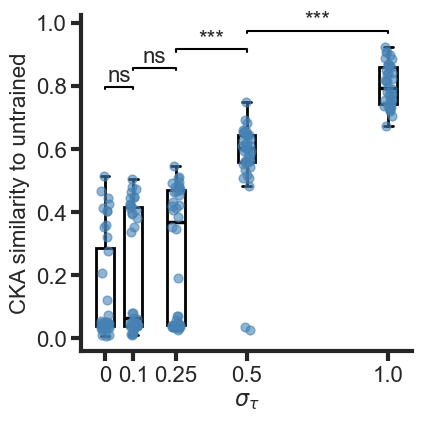

In [15]:
from scipy.stats import mannwhitneyu

fig, ax = plt.subplots(figsize=(4.5, 4.5))

data = [allckas[eta] for eta in etas]
labels = [0, 0.1, 0.25, 0.5, 1.0]
pos = [0, 0.4, 1.0, 2.0, 4.0]
widths = 0.15 # relative to pos spacing — tune as needed

rng = np.random.default_rng(0)
for d, p in zip(data, pos):
    d_clean = np.array(d)
    mask = ~np.isnan(d_clean)
    jitter = rng.uniform(-0.06, 0.06, size=mask.sum())
    ax.scatter(p + jitter, d_clean[mask], color="steelblue", alpha=0.6, s=40, zorder=3)

ax.boxplot(
    data,
    positions=pos,
    widths=0.25, # was 0.15
    manage_ticks=False,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black", linewidth=2), # added linewidth
    medianprops=dict(color="black", linewidth=2.5), # was 2
    whiskerprops=dict(color="black", linewidth=2), # added linewidth
    capprops=dict(color="black", linewidth=2), # added linewidth
    flierprops=dict(marker=""),
)

# Fixed significance label
def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

n_comparisons = len(pos) - 1
y_max = max(max(d) for d in data)
bar_gap = y_max * 0.08

for i in range(n_comparisons):
    p1, p2 = pos[i], pos[i+1]

    d1 = np.array(data[i])
    d2 = np.array(data[i+1])

    d1_clean = d1[~np.isnan(d1)]
    d2_clean = d2[~np.isnan(d2)]

    print(f"eta {labels[i]} vs {labels[i+1]}: n={len(d1_clean)}/{len(d1)}, {len(d2_clean)}/{len(d2)} after dropping NaNs")

    _, p_val = mannwhitneyu(d1_clean, d2_clean, alternative='two-sided')
    p_corrected = min(p_val * n_comparisons, 1.0)
    label = significance_label(p_corrected)
    print(f" raw p={p_val:.4f}, corrected p={p_corrected:.4f} → {label}")
    label = significance_label(p_corrected)
    print(f"eta {labels[i]} vs {labels[i+1]}: raw p={p_val:.4f}, corrected p={p_corrected:.4f} → {label}")

    bar_y = y_max + bar_gap * (i + 1)
    bar_y = bar_y*0.8
    ax.plot([p1, p1, p2, p2], [bar_y - bar_gap*0.1, bar_y, bar_y, bar_y - bar_gap*0.1],
            color='black', linewidth=1.5)
    ax.text((p1 + p2) / 2, bar_y + bar_gap * 0.05, label,
            ha='center', va='bottom')

ax.set_xticks(pos)
ax.set_xticklabels(labels)
ax.set_ylabel('CKA similarity to untrained')
# ax.set_ylim(0,1)
ax.set_xlabel(r'$\sigma_{\tau}$')

plt.tight_layout()
plt.show()